## Notebook 05 — LSTM Macroeconomic State Preparation

### Purpose

This notebook prepares and validates the macroeconomic information set used by the recurrent component of the deep asset-pricing model.

The macro panel contains **178 monthly state variables** covering January 1967 through December 2016. The sample is divided chronologically into:

- **Training:** 1967–1986, 240 months
- **Validation:** 1987–1991, 60 months
- **Test:** 1992–2016, 300 months

The processed macro panel used in this notebook was verified against the author-provided `macro_train.npz`, `macro_valid.npz`, and `macro_test.npz` files. The numerical values are identical up to machine precision; differences in variable names arise only from formatting such as capitalization and replacement of spaces with underscores.

### Preprocessing

All 178 macro variables are standardized using **training-period means and standard deviations only**. The same training-period transformation is then applied to the validation and test samples. This prevents look-ahead bias and preserves a genuinely out-of-sample evaluation.

Some test-period standardized observations are very large, particularly the `nonborres` series during the 2008–2009 financial crisis. These observations are present in the original author data and are therefore retained without clipping or winsorization.

### LSTM State Representation

Two recurrent macro encoders are defined:

- **SDF macro encoder:** 178 inputs → 4 LSTM hidden states
- **Conditional/adversarial macro encoder:** 178 inputs → 32 LSTM hidden states

The macro data are treated as one continuous monthly time series. Recurrent hidden and cell states are therefore carried forward across the training, validation, and test boundaries rather than reset at each split.

This notebook focuses on data preparation, architecture validation, and recurrent-state mechanics. The economically meaningful LSTM states will ultimately be learned jointly with the asset-pricing objective in the subsequent GAN stage.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.14.0
Device : mps


## 2. Locate the repository

The notebook is expected to live in `notebooks/`. This cell searches upward until it finds the project root containing both `data/` and `notebooks/`.

In [2]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing "
        "'data/' and 'notebooks/'."
    )


REPO_ROOT = find_repo_root()

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
RESULTS_DIR = REPO_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"
MACRO_DIR = RESULTS_DIR / "macro"

for directory in [
    TABLES_DIR,
    MODELS_DIR,
    MACRO_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Processed data :", PROCESSED_DIR)
print("Macro outputs  :", MACRO_DIR)

Repository root: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
Processed data : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/processed
Macro outputs  : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/macro


## 3. Configuration

The paper's SDF network uses four macro hidden states, while the conditional adversarial network uses 32 hidden states.

We use a one-layer PyTorch LSTM cell for each encoder. The number `4` or `32` is the dimensionality of the hidden state, not the number of stacked recurrent layers.

In [3]:
DATE_COL_CANDIDATES = [
    "date",
    "yyyymm",
    "month",
    "caldt",
    "time",
]

EXPECTED_MACRO_FEATURES = 178

SDF_MACRO_HIDDEN_DIM = 4
COND_MACRO_HIDDEN_DIM = 32

LSTM_NUM_LAYERS = 1

TRAIN_START = pd.Timestamp("1967-01-01")
TRAIN_END = pd.Timestamp("1986-12-01")

VALID_START = pd.Timestamp("1987-01-01")
VALID_END = pd.Timestamp("1991-12-01")

TEST_START = pd.Timestamp("1992-01-01")
TEST_END = pd.Timestamp("2016-12-01")

FULL_START = TRAIN_START
FULL_END = TEST_END

print("Expected macro features :", EXPECTED_MACRO_FEATURES)
print("SDF hidden states       :", SDF_MACRO_HIDDEN_DIM)
print("Conditional hidden states:", COND_MACRO_HIDDEN_DIM)
print("LSTM layers             :", LSTM_NUM_LAYERS)

Expected macro features : 178
SDF hidden states       : 4
Conditional hidden states: 32
LSTM layers             : 1


## 4. Load the processed macroeconomic panel

`01_data_preparation.ipynb` saves `data/processed/macro_processed.parquet` when the project `Macro.csv` is available. We use that file first.

If the combined file is unavailable but the three split files exist, this cell reconstructs the full panel by concatenating them.

No additional generic differencing or logging is applied here. The paper uses series-specific transformation codes, so a processed project macro file should not be transformed again blindly.

In [5]:
combined_macro_path = (
    PROCESSED_DIR / "macro_processed.parquet"
)

split_macro_paths = {
    "train": PROCESSED_DIR / "macro_train.parquet",
    "validation": (
        PROCESSED_DIR / "macro_validation.parquet"
    ),
    "test": PROCESSED_DIR / "macro_test.parquet",
}

if combined_macro_path.exists():

    macro = pd.read_parquet(
        combined_macro_path
    )

    macro_source = combined_macro_path

elif all(
    path.exists()
    for path in split_macro_paths.values()
):

    macro = pd.concat(
        [
            pd.read_parquet(
                split_macro_paths["train"]
            ),
            pd.read_parquet(
                split_macro_paths["validation"]
            ),
            pd.read_parquet(
                split_macro_paths["test"]
            ),
        ],
        ignore_index=True,
    )

    macro_source = "concatenated split files"

else:

    raise FileNotFoundError(
        "No processed macro panel was found. "
        "Run 01_data_preparation.ipynb with Macro.csv "
        "available before continuing."
    )

print("Macro source:", macro_source)
print("Raw loaded shape:", macro.shape)
display(macro.head())

Macro source: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/processed/macro_processed.parquet
Raw loaded shape: (600, 179)


,date,rpi,w875rx1,dpcera3m086sbea,cmrmtsplx,retailx,indpro,ipfpnss,ipfinal,ipcongd,ipdcongd,ipncongd,ipbuseq,ipmat,ipdmat,ipnmat,ipmansics,ipb51222s,ipfuels,cumfns,hwi,hwiuratio,clf16ov,ce16ov,unrate,uempmean,uemplt5,uemp5to14,uemp15ov,uemp15t26,uemp27ov,claimsx,payems,usgood,ces1021000001,uscons,manemp,dmanemp,ndmanemp,srvprd,ustpu,uswtrade,ustrade,usfire,usgovt,ces0600000007,awotman,awhman,houst,houstne,houstmw,housts,houstw,permit,permitne,permitmw,permits,permitw,amdmnox,amdmuox,businvx,isratiox,m1sl,m2sl,m2real,ambsl,totresns,nonborres,busloans,realln,nonrevsl,conspi,s&p_500,s&p:_indust,s&p_div_yield,s&p_pe_ratio,fedfunds,cp3mx,tb3ms,tb6ms,gs1,gs5,gs10,aaa,baa,compapffx,tb3smffm,tb6smffm,t1yffm,t5yffm,t10yffm,aaaffm,baaffm,exszusx,exjpusx,exusukx,excausx,wpsfd49207,wpsfd49502,wpsid61,wpsid62,oilpricex,ppicmm,cpiaucsl,cpiappsl,cpitrnsl,cpimedsl,cusr0000sac,cusr0000sad,cusr0000sas,cpiulfsl,cusr0000sa0l2,cusr0000sa0l5,pcepi,ddurrg3m086sbea,dndgrg3m086sbea,dserrg3m086sbea,ces0600000008,ces2000000008,ces3000000008,mzmsl,dtcolnvhfnm,dtcthfnm,invest,vxoclsx,a2me,ac,at,ato,beme,beta,c,cf,cf2p,cto,d2a,d2p,dpi2a,e2p,fc2y,idiovol,investment,lev,lme,lt_rev,lturnover,mktbeta,ni,noa,oa,ol,op,pcm,pm,prof,q,r2_1,r12_2,r12_7,r36_13,rel2high,resid_var,rna,roa,roe,s2p,sga2s,spread,st_rev,suv,variance,dp,ep,b/m,ntis,tbl,tms,dfy,svar
0,1967-01-01,-0.000262,-0.001279,0.001592,0.000467,-0.007144,0.002307,0.003122,0.003071,-0.002476,-0.010598,0.000853,0.013831,-0.000003,-0.005039,0.006903,0.004566,-0.002363,-0.005531,-0.104700,-38.000000,-0.069946,0.000405,-0.001504,0.200000,-0.200000,0.053892,-0.040768,0.050431,0.051672,0.048790,0.059308,0.002780,0.000909,0.001471,0.001206,0.000945,0.000905,0.001008,0.003735,0.003050,0.002656,0.004157,0.003671,0.004720,40.600000,-0.300000,40.900000,6.897705,5.187386,5.488938,6.013715,5.075174,6.610696,5.017280,5.170484,5.652489,4.875197,-0.002898,0.003749,0.008738,0.010331,0.002327,0.002700,0.004879,0.000275,0.030092,0.028958,0.003037,0.001284,-0.001333,0.000275,0.004189,0.004635,-0.023050,0.000803,-0.360000,0.000000,-0.360000,-0.470000,-0.340000,-0.360000,-0.320000,0.040000,0.050000,0.600000,-0.440000,-0.330000,-0.200000,-0.400000,-0.560000,-0.010000,0.780000,0.000532,0.000036,-0.000358,0.000831,-0.002821,-0.002829,-0.003110,0.012194,0.000000,-0.010369,0.000303,0.002002,-0.009170,-0.003724,0.000000,-0.002567,-0.007117,-0.003053,0.000000,0.002999,0.000547,0.004128,0.000202,-0.000377,-0.003591,-0.002894,-0.007561,0.001646,-0.000673,0.011262,0.015138,15.292800,0.000000,0.000000,0.000000,0.000000,0.000000,0.966799,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.248490,0.000000,0.000000,0.000944,0.037798,0.354102,1.088351,0.002740,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.024193,-0.013124,-0.035842,0.037130,0.014519,-0.038626,0.000000,0.000000,0.000000,0.000000,0.000000,0.026759,-0.010710,0.461402,-0.115399,-0.000829,0.003897,0.007481,-0.000341,-0.003600,-0.004100,0.000100,-0.211208
1,1967-02-01,0.009231,0.008679,0.004719,-0.013455,-0.049586,0.004707,0.010373,0.007179,0.009027,-0.025277,0.022914,-0.007057,-0.004207,-0.001682,-0.003099,0.002981,0.025411,0.007101,-0.182100,26.000000,-0.011935,-0.000026,-0.000787,0.100000,-0.200000,0.016301,0.136547,0.002047,0.028371,-0.033902,-0.034462,0.003170,0.002224,-0.000980,0.003310,0.001943,-0.000271,0.005456,0.003651,0.002028,0.001756,0.000045,0.003326,0.005228,40.800000,0.000000,41.100000,6.972606,5.365976,5.659482,6.075346,4.875197,6.902743,5.666427,5.455321,5.774552,5.010635,-0.022886,0.002567,0.010906,0.000000,-0.004076,-0.003146,0.003490,0.001531,-0.010585,-0.009108,-0.003903,-0.000970,0.000571,-0.000835,0.037645,0.038331,-0.118531,0.034911,-0.460000,-0.270000,-0.240000,-0.330000,-0.450000,-0.300000,-0.260000,-0.190000,-0.210000,0.790000,-0.220000,-0.200000,-0.190000,-0.240000,-0.360000,0.260000,1.030000,0.001733,0.000000,0.000323,-0.003329,0.002821,0.005634,0.000000,0.009322,0.000000,0.028164,-0.001824,

In [11]:
# ==================================================
# 4B. Compare processed parquet with author NPZ files
# ==================================================

from pathlib import Path
import numpy as np
import pandas as pd

DATASETS_DIR = Path.cwd().parents[2] / "datasets"
MACRO_NPZ_DIR = DATASETS_DIR / "macro"

# -----------------------------
# Load author NPZ arrays
# -----------------------------

train_npz = np.load(
    MACRO_NPZ_DIR / "macro_train.npz"
)

valid_npz = np.load(
    MACRO_NPZ_DIR / "macro_valid.npz"
)

test_npz = np.load(
    MACRO_NPZ_DIR / "macro_test.npz"
)

npz_data = np.vstack([
    train_npz["data"],
    valid_npz["data"],
    test_npz["data"],
])

npz_variables = (
    train_npz["variable"]
    .astype(str)
)

print("NPZ combined shape:", npz_data.shape)
print("NPZ variables     :", len(npz_variables))


# -----------------------------
# Extract parquet data
# -----------------------------

parquet_feature_cols = [
    c for c in macro.columns
    if c != DATE_COL
]

parquet_data = (
    macro[parquet_feature_cols]
    .to_numpy(dtype=float)
)

print("Parquet data shape:", parquet_data.shape)
print("Parquet variables :", len(parquet_feature_cols))


# -----------------------------
# Compare variable names
# -----------------------------

same_variables = np.array_equal(
    np.array(parquet_feature_cols).astype(str),
    npz_variables,
)

print(
    "\nSame variable names/order:",
    same_variables,
)


# -----------------------------
# Compare numerical values
# -----------------------------

same_values = np.allclose(
    parquet_data,
    npz_data,
    rtol=1e-10,
    atol=1e-12,
)

max_difference = np.max(
    np.abs(
        parquet_data - npz_data
    )
)

print(
    "Same numerical values:",
    same_values,
)

print(
    "Maximum absolute difference:",
    max_difference,
)

NPZ combined shape: (600, 178)
NPZ variables     : 178
Parquet data shape: (600, 178)
Parquet variables : 178

Same variable names/order: False
Same numerical values: True
Maximum absolute difference: 7.105427357601002e-15


In [12]:
# ==================================================
# 4C. Inspect macro variable-name differences
# ==================================================

name_comparison = pd.DataFrame({
    "position": np.arange(len(npz_variables)),
    "author_npz_name": npz_variables,
    "parquet_name": parquet_feature_cols,
})

name_comparison["same"] = (
    name_comparison["author_npz_name"]
    == name_comparison["parquet_name"]
)

different_names = (
    name_comparison.loc[
        ~name_comparison["same"]
    ]
    .reset_index(drop=True)
)

print(
    "Number of different names:",
    len(different_names),
)

display(
    different_names.head(30)
)

Number of different names: 166


,position,author_npz_name,parquet_name,same
0,0,RPI,rpi,False
1,1,W875RX1,w875rx1,False
2,2,DPCERA3M086SBEA,dpcera3m086sbea,False
3,3,CMRMTSPLx,cmrmtsplx,False
4,4,RETAILx,retailx,False
5,5,INDPRO,indpro,False
6,6,IPFPNSS,ipfpnss,False
7,7,IPFINAL,ipfinal,False
8,8,IPCONGD,ipcongd,False
9,9,IPDCONGD,ipdcongd,False


In [13]:
# ==================================================
# 4D. Check normalized macro variable names
# ==================================================

def normalize_macro_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "")
    )


author_normalized = np.array([
    normalize_macro_name(x)
    for x in npz_variables
])

parquet_normalized = np.array([
    normalize_macro_name(x)
    for x in parquet_feature_cols
])

same_after_normalization = np.array_equal(
    author_normalized,
    parquet_normalized,
)

print(
    "Same names after normalization:",
    same_after_normalization,
)

if not same_after_normalization:

    remaining = pd.DataFrame({
        "position": np.arange(
            len(npz_variables)
        ),
        "author_name": npz_variables,
        "parquet_name": parquet_feature_cols,
        "author_normalized": author_normalized,
        "parquet_normalized": parquet_normalized,
    })

    remaining = remaining.loc[
        remaining["author_normalized"]
        != remaining["parquet_normalized"]
    ]

    print(
        "Remaining mismatches:",
        len(remaining),
    )

    display(
        remaining.head(30)
    )

Same names after normalization: False
Remaining mismatches: 4


,position,author_name,parquet_name,author_normalized,parquet_normalized
71,71,S&P 500,s&p_500,s&p500,s&p_500
72,72,S&P: indust,s&p:_indust,s&p:indust,s&p:_indust
73,73,S&P div yield,s&p_div_yield,s&pdivyield,s&p_div_yield
74,74,S&P PE ratio,s&p_pe_ratio,s&pperatio,s&p_pe_ratio


In [14]:
# ==================================================
# 4E. Final normalized-name equivalence check
# ==================================================

def normalize_macro_name_final(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("_", "")
    )


author_final = np.array([
    normalize_macro_name_final(x)
    for x in npz_variables
])

parquet_final = np.array([
    normalize_macro_name_final(x)
    for x in parquet_feature_cols
])

print(
    "Same names after final normalization:",
    np.array_equal(
        author_final,
        parquet_final,
    )
)

Same names after final normalization: True


## 5. Detect and standardize the date field

In [15]:
def detect_date_column(columns):

    lower_map = {
        str(c).lower(): c
        for c in columns
    }

    for candidate in DATE_COL_CANDIDATES:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    raise ValueError(
        "Could not identify the macro date column."
    )


def parse_monthly_date(series):

    if pd.api.types.is_datetime64_any_dtype(
        series
    ):
        out = pd.to_datetime(series)

    else:
        text = series.astype(str).str.strip()

        # YYYYMM integer/string
        yyyymm_mask = text.str.fullmatch(
            r"\d{6}(\.0)?"
        )

        if yyyymm_mask.all():
            text = text.str.replace(
                ".0",
                "",
                regex=False,
            )
            out = pd.to_datetime(
                text,
                format="%Y%m",
            )
        else:
            out = pd.to_datetime(
                series,
                errors="coerce",
            )

    return (
        out
        .dt.to_period("M")
        .dt.to_timestamp()
    )


DATE_COL = detect_date_column(
    macro.columns
)

macro = macro.copy()

macro[DATE_COL] = parse_monthly_date(
    macro[DATE_COL]
)

macro = (
    macro
    .dropna(subset=[DATE_COL])
    .sort_values(DATE_COL)
    .drop_duplicates(
        subset=[DATE_COL],
        keep="last",
    )
    .reset_index(drop=True)
)

print("Date column:", DATE_COL)
print(
    "Coverage:",
    macro[DATE_COL].min(),
    "to",
    macro[DATE_COL].max(),
)
print("Unique months:", macro[DATE_COL].nunique())

Date column: date
Coverage: 1967-01-01 00:00:00 to 2016-12-01 00:00:00
Unique months: 600


## 6. Identify macroeconomic features

The replication target is 178 numeric macroeconomic predictors plus the date column.

In [16]:
macro_feature_cols = [
    c
    for c in macro.columns
    if (
        c != DATE_COL
        and pd.api.types.is_numeric_dtype(
            macro[c]
        )
    )
]

non_numeric_non_date = [
    c
    for c in macro.columns
    if (
        c != DATE_COL
        and c not in macro_feature_cols
    )
]

print(
    "Numeric macro features:",
    len(macro_feature_cols),
)

if non_numeric_non_date:
    print(
        "Non-numeric non-date columns:",
        non_numeric_non_date,
    )

print(
    "First 20 macro features:",
    macro_feature_cols[:20],
)

if (
    len(macro_feature_cols)
    != EXPECTED_MACRO_FEATURES
):
    print(
        "\nWARNING:"
        f" expected {EXPECTED_MACRO_FEATURES} "
        f"macro features but found "
        f"{len(macro_feature_cols)}."
    )
else:
    print(
        "✓ 178-feature macro information set verified."
    )

Numeric macro features: 178
First 20 macro features: ['rpi', 'w875rx1', 'dpcera3m086sbea', 'cmrmtsplx', 'retailx', 'indpro', 'ipfpnss', 'ipfinal', 'ipcongd', 'ipdcongd', 'ipncongd', 'ipbuseq', 'ipmat', 'ipdmat', 'ipnmat', 'ipmansics', 'ipb51222s', 'ipfuels', 'cumfns', 'hwi']
✓ 178-feature macro information set verified.


## 7. Restrict to the paper sample and verify all 600 months

The target sample is January 1967 through December 2016.

In [17]:
macro = (
    macro.loc[
        macro[DATE_COL].between(
            FULL_START,
            FULL_END,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

expected_dates = pd.date_range(
    FULL_START,
    FULL_END,
    freq="MS",
)

observed_dates = pd.DatetimeIndex(
    macro[DATE_COL]
)

missing_dates = expected_dates.difference(
    observed_dates
)

extra_dates = observed_dates.difference(
    expected_dates
)

print("Filtered shape:", macro.shape)
print("Months        :", len(macro))
print(
    "Coverage      :",
    macro[DATE_COL].min(),
    "to",
    macro[DATE_COL].max(),
)
print("Missing months:", len(missing_dates))
print("Extra months  :", len(extra_dates))

if len(missing_dates) > 0:
    print(
        "Missing:",
        list(missing_dates[:20]),
    )

assert len(macro) == 600, (
    "Expected exactly 600 monthly observations."
)

assert len(missing_dates) == 0, (
    "The macro panel has missing sample months."
)

print("✓ Exact 600-month macro sample verified.")

Filtered shape: (600, 179)
Months        : 600
Coverage      : 1967-01-01 00:00:00 to 2016-12-01 00:00:00
Missing months: 0
Extra months  : 0
✓ Exact 600-month macro sample verified.


## 8. Missing-value and finite-value diagnostics

The final LSTM input cannot contain NaN or infinite values. We inspect the processed macro file before any standardization.

In [18]:
macro_numeric = (
    macro[macro_feature_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

missing_by_feature = (
    macro_numeric
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_total = int(
    missing_by_feature.sum()
)

print("Total missing values:", missing_total)

if missing_total > 0:
    display(
        missing_by_feature[
            missing_by_feature > 0
        ].to_frame("missing_count")
    )
else:
    print("✓ No missing macro values.")

finite_share = (
    np.isfinite(
        macro_numeric.to_numpy(
            dtype=float
        )
    )
    .mean()
)

print(
    "Finite-value share:",
    f"{finite_share:.6f}",
)

Total missing values: 0
✓ No missing macro values.
Finite-value share: 1.000000


## 9. Fixed chronological split

The macro split must match the stock-return split exactly: 240 / 60 / 300 months.

In [19]:
train_mask = macro[DATE_COL].between(
    TRAIN_START,
    TRAIN_END,
)

valid_mask = macro[DATE_COL].between(
    VALID_START,
    VALID_END,
)

test_mask = macro[DATE_COL].between(
    TEST_START,
    TEST_END,
)

macro_train = (
    macro.loc[train_mask]
    .copy()
    .reset_index(drop=True)
)

macro_valid = (
    macro.loc[valid_mask]
    .copy()
    .reset_index(drop=True)
)

macro_test = (
    macro.loc[test_mask]
    .copy()
    .reset_index(drop=True)
)

print(
    "Train     :",
    macro_train.shape,
    "| months:",
    len(macro_train),
)

print(
    "Validation:",
    macro_valid.shape,
    "| months:",
    len(macro_valid),
)

print(
    "Test      :",
    macro_test.shape,
    "| months:",
    len(macro_test),
)

assert len(macro_train) == 240
assert len(macro_valid) == 60
assert len(macro_test) == 300

print("✓ 240 / 60 / 300 macro split verified.")

Train     : (240, 179) | months: 240
Validation: (60, 179) | months: 60
Test      : (300, 179) | months: 300
✓ 240 / 60 / 300 macro split verified.


In [23]:
# ==================================================
# 9B. Diagnose extreme standardized macro values
#     Self-contained version for current notebook
# ==================================================

import numpy as np
import pandas as pd

# 178 macro feature columns
feature_cols = [
    c for c in macro.columns
    if c != DATE_COL
]

# Exact chronological splits
train_df = macro.iloc[:240].copy()
valid_df = macro.iloc[240:300].copy()
test_df  = macro.iloc[300:].copy()

# Raw matrices
Xtr_raw = train_df[feature_cols].to_numpy(dtype=float)
Xte_raw = test_df[feature_cols].to_numpy(dtype=float)

# Training-only scaler
mu = Xtr_raw.mean(axis=0)
sigma = Xtr_raw.std(axis=0, ddof=0)

safe_sigma = sigma.copy()
safe_sigma[safe_sigma < 1e-12] = 1.0

# Standardized test matrix
Xte = (Xte_raw - mu) / safe_sigma

# Find largest absolute standardized value
row_idx, col_idx = np.unravel_index(
    np.abs(Xte).argmax(),
    Xte.shape
)

feature_name = feature_cols[col_idx]
test_date = test_df.iloc[row_idx][DATE_COL]

print("Largest absolute test z-score")
print("--------------------------------")
print("Date       :", test_date)
print("Feature    :", feature_name)
print("Column idx :", col_idx)
print("Raw value  :", Xte_raw[row_idx, col_idx])
print("Train mean :", mu[col_idx])
print("Train std  :", sigma[col_idx])
print("Z-score    :", Xte[row_idx, col_idx])


# Top 10 most extreme observations
flat_idx = np.argsort(
    np.abs(Xte).ravel()
)[-10:][::-1]

rows, cols = np.unravel_index(
    flat_idx,
    Xte.shape
)

extreme_table = pd.DataFrame({
    "date": [
        test_df.iloc[r][DATE_COL]
        for r in rows
    ],
    "feature": [
        feature_cols[c]
        for c in cols
    ],
    "raw_value": [
        Xte_raw[r, c]
        for r, c in zip(rows, cols)
    ],
    "train_mean": [
        mu[c]
        for c in cols
    ],
    "train_std": [
        sigma[c]
        for c in cols
    ],
    "z_score": [
        Xte[r, c]
        for r, c in zip(rows, cols)
    ],
})

display(extreme_table)

Largest absolute test z-score
--------------------------------
Date       : 2008-03-01 00:00:00
Feature    : nonborres
Column idx : 66
Raw value  : 21.26800412684716
Train mean : 0.00014396270815218032
Train std  : 0.03573135615022509
Z-score    : 595.2155880880282


,date,feature,raw_value,train_mean,train_std,z_score
0,2008-03-01,nonborres,21.268004,0.000144,0.035731,595.215588
1,2008-04-01,nonborres,-18.133617,0.000144,0.035731,-507.502745
2,2009-02-01,nonborres,3.639846,0.000144,0.035731,101.862974
3,2009-01-01,nonborres,-2.135067,0.000144,0.035731,-59.757358
4,2008-12-01,nonborres,-1.512716,0.000144,0.035731,-42.339853
5,2009-03-01,nonborres,-1.374361,0.000144,0.035731,-38.467758
6,2008-05-01,nonborres,-1.326151,0.000144,0.035731,-37.118524
7,2009-01-01,ambsl,-0.139799,0.000035,0.004923,-28.406741
8,2009-04-01,nonborres,1.002217,0.000144,0.035731,28.044646
9,2009-07-01,roa,-1.148601,-0.003353,0.041760,-27.424630


## 10. Standardize macro variables using training statistics only

The authors' evaluation code computes macro means and standard deviations from the training data and passes those same statistics to validation and test.

We therefore fit the scaler **only on 1967–1986**.

No validation or test information is used to estimate means or standard deviations.

In [24]:
X_train_raw = (
    macro_train[macro_feature_cols]
    .to_numpy(dtype=np.float64)
)

train_mean = np.nanmean(
    X_train_raw,
    axis=0,
)

train_std = np.nanstd(
    X_train_raw,
    axis=0,
    ddof=0,
)

zero_std_mask = (
    ~np.isfinite(train_std)
    | (train_std < 1e-12)
)

print(
    "Zero / invalid training std features:",
    int(zero_std_mask.sum()),
)

safe_train_std = train_std.copy()

safe_train_std[
    zero_std_mask
] = 1.0

macro_standardized = macro.copy()

macro_standardized[
    macro_feature_cols
] = (
    macro[macro_feature_cols]
    .to_numpy(dtype=np.float64)
    - train_mean
) / safe_train_std

print("✓ Training-only macro standardization complete.")

Zero / invalid training std features: 0
✓ Training-only macro standardization complete.


## 11. Standardization diagnostics

Training features should have means close to zero and standard deviations close to one, apart from any zero-variance features.

In [25]:
std_train = (
    macro_standardized.loc[
        train_mask,
        macro_feature_cols,
    ]
)

std_valid = (
    macro_standardized.loc[
        valid_mask,
        macro_feature_cols,
    ]
)

std_test = (
    macro_standardized.loc[
        test_mask,
        macro_feature_cols,
    ]
)

standardization_diagnostics = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test",
        ],
        "mean_of_feature_means": [
            std_train.mean().mean(),
            std_valid.mean().mean(),
            std_test.mean().mean(),
        ],
        "mean_absolute_feature_mean": [
            std_train.mean().abs().mean(),
            std_valid.mean().abs().mean(),
            std_test.mean().abs().mean(),
        ],
        "mean_feature_std": [
            std_train.std(
                ddof=0
            ).mean(),
            std_valid.std(
                ddof=0
            ).mean(),
            std_test.std(
                ddof=0
            ).mean(),
        ],
        "maximum_abs_value": [
            std_train.abs().max().max(),
            std_valid.abs().max().max(),
            std_test.abs().max().max(),
        ],
    }
)

display(standardization_diagnostics)

assert np.isfinite(
    macro_standardized[
        macro_feature_cols
    ].to_numpy(dtype=float)
).all()

print("✓ Standardized macro panel is finite.")

,split,mean_of_feature_means,mean_absolute_feature_mean,mean_feature_std,maximum_abs_value
0,train,-0.000000,0.000000,1.000000,13.116102
1,validation,-0.053184,0.136228,0.780303,12.092470
2,test,-0.052679,0.185636,1.272279,595.215588


✓ Standardized macro panel is finite.


## 12. Prepare sequential tensors

The LSTM is recursive. We therefore preserve the full chronological sequence rather than randomly shuffling months.

Each split tensor has shape:

`[batch = 1, time, macro_features = 178]`

In [27]:
def macro_tensor(df):

    array = (
        df[macro_feature_cols]
        .to_numpy(dtype=np.float32)
    )

    return torch.tensor(
        array,
        dtype=torch.float32,
    ).unsqueeze(0)


macro_std_train = (
    macro_standardized.loc[
        train_mask
    ]
    .copy()
    .reset_index(drop=True)
)

macro_std_valid = (
    macro_standardized.loc[
        valid_mask
    ]
    .copy()
    .reset_index(drop=True)
)

macro_std_test = (
    macro_standardized.loc[
        test_mask
    ]
    .copy()
    .reset_index(drop=True)
)

X_macro_train = macro_tensor(
    macro_std_train
)

X_macro_valid = macro_tensor(
    macro_std_valid
)

X_macro_test = macro_tensor(
    macro_std_test
)

print(
    "Train tensor     :",
    tuple(X_macro_train.shape),
)

print(
    "Validation tensor:",
    tuple(X_macro_valid.shape),
)

print(
    "Test tensor      :",
    tuple(X_macro_test.shape),
)

Train tensor     : (1, 240, 178)
Validation tensor: (1, 60, 178)
Test tensor      : (1, 300, 178)


## 13. Define a causal macro LSTM encoder

The output at month `t` depends only on current and previous macro information.

The same generic encoder will later be used in Code 06 with:

- hidden dimension **4** for the SDF network;
- hidden dimension **32** for the adversarial conditioning network.

In [28]:
class MacroLSTMEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_layers=1,
    ):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

    def zero_state(
        self,
        batch_size,
        device=None,
    ):

        if device is None:
            device = next(
                self.parameters()
            ).device

        h0 = torch.zeros(
            self.num_layers,
            batch_size,
            self.hidden_dim,
            device=device,
        )

        c0 = torch.zeros(
            self.num_layers,
            batch_size,
            self.hidden_dim,
            device=device,
        )

        return h0, c0

    def forward(
        self,
        x,
        state=None,
    ):

        if state is None:
            state = self.zero_state(
                batch_size=x.shape[0],
                device=x.device,
            )

        outputs, next_state = self.lstm(
            x,
            state,
        )

        return outputs, next_state

## 14. Instantiate the two paper-style macro encoders

These models are **untrained** in Code 05. They are instantiated only to verify architecture, dimensions, causality, and state carryover.

In [29]:
sdf_macro_encoder = MacroLSTMEncoder(
    input_dim=len(macro_feature_cols),
    hidden_dim=SDF_MACRO_HIDDEN_DIM,
    num_layers=LSTM_NUM_LAYERS,
).to(DEVICE)

cond_macro_encoder = MacroLSTMEncoder(
    input_dim=len(macro_feature_cols),
    hidden_dim=COND_MACRO_HIDDEN_DIM,
    num_layers=LSTM_NUM_LAYERS,
).to(DEVICE)


def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print("SDF macro encoder:")
print(sdf_macro_encoder)
print(
    "Trainable parameters:",
    count_parameters(
        sdf_macro_encoder
    ),
)

print()
print("Conditional macro encoder:")
print(cond_macro_encoder)
print(
    "Trainable parameters:",
    count_parameters(
        cond_macro_encoder
    ),
)

SDF macro encoder:
MacroLSTMEncoder(
  (lstm): LSTM(178, 4, batch_first=True)
)
Trainable parameters: 2944

Conditional macro encoder:
MacroLSTMEncoder(
  (lstm): LSTM(178, 32, batch_first=True)
)
Trainable parameters: 27136


## 15. Forward-pass shape test with carried recurrent states

We process training first, pass its terminal state into validation, and then pass the validation terminal state into test.

This mirrors the chronological state propagation used by the authors' evaluation code.

In [30]:
sdf_macro_encoder.eval()

with torch.no_grad():

    train_states, state_after_train = (
        sdf_macro_encoder(
            X_macro_train.to(DEVICE)
        )
    )

    valid_states, state_after_valid = (
        sdf_macro_encoder(
            X_macro_valid.to(DEVICE),
            state_after_train,
        )
    )

    test_states, state_after_test = (
        sdf_macro_encoder(
            X_macro_test.to(DEVICE),
            state_after_valid,
        )
    )

print(
    "Train hidden states     :",
    tuple(train_states.shape),
)

print(
    "Validation hidden states:",
    tuple(valid_states.shape),
)

print(
    "Test hidden states      :",
    tuple(test_states.shape),
)

assert train_states.shape == (
    1,
    240,
    SDF_MACRO_HIDDEN_DIM,
)

assert valid_states.shape == (
    1,
    60,
    SDF_MACRO_HIDDEN_DIM,
)

assert test_states.shape == (
    1,
    300,
    SDF_MACRO_HIDDEN_DIM,
)

print("✓ Recurrent-state shapes verified.")

Train hidden states     : (1, 240, 4)
Validation hidden states: (1, 60, 4)
Test hidden states      : (1, 300, 4)
✓ Recurrent-state shapes verified.


## 16. Split-carryover equivalence test

Processing all 600 months in one call should produce the same hidden-state path as processing train, validation, and test sequentially while carrying the recurrent state forward.

This is an important implementation check for Code 06.

In [32]:
X_macro_full = torch.cat(
    [
        X_macro_train,
        X_macro_valid,
        X_macro_test,
    ],
    dim=1,
).to(DEVICE)

sdf_macro_encoder.eval()

with torch.no_grad():

    states_full, _ = (
        sdf_macro_encoder(
            X_macro_full
        )
    )

    states_split = torch.cat(
        [
            train_states,
            valid_states,
            test_states,
        ],
        dim=1,
    )

carryover_max_difference = (
    states_full
    .sub(states_split)
    .abs()
    .max()
    .item()
)

print(
    "Maximum full-vs-split state difference:",
    f"{carryover_max_difference:.12e}",
)

assert torch.allclose(
    states_full,
    states_split,
    atol=1e-6,
    rtol=1e-6,
)

print(
    "✓ Split processing with carried states "
    "matches full-sequence processing."
)

Maximum full-vs-split state difference: 0.000000000000e+00
✓ Split processing with carried states matches full-sequence processing.


## 17. No-look-ahead causality test

We perturb future macro observations and verify that previously computed hidden states do not change.

This confirms the recurrent encoder is causal.

In [34]:
cutoff = 300

X_original = X_macro_full.clone()

X_perturbed = X_macro_full.clone()

torch.manual_seed(SEED)

X_perturbed[
    :,
    cutoff:,
    :
] = (
    X_perturbed[
        :,
        cutoff:,
        :
    ]
    + 10.0
    * torch.randn_like(
        X_perturbed[
            :,
            cutoff:,
            :
        ]
    )
)

sdf_macro_encoder.eval()

with torch.no_grad():

    states_original, _ = (
        sdf_macro_encoder(
            X_original
        )
    )

    states_perturbed, _ = (
        sdf_macro_encoder(
            X_perturbed
        )
    )

past_difference = (
    states_original[
        :,
        :cutoff,
        :
    ]
    .sub(
        states_perturbed[
            :,
            :cutoff,
            :
        ]
    )
    .abs()
    .max()
    .item()
)

future_difference = (
    states_original[
        :,
        cutoff:,
        :
    ]
    .sub(
        states_perturbed[
            :,
            cutoff:,
            :
        ]
    )
    .abs()
    .max()
    .item()
)

print(
    "Maximum difference before cutoff:",
    f"{past_difference:.12e}",
)

print(
    "Maximum difference after cutoff :",
    f"{future_difference:.6f}",
)

assert past_difference < 1e-6

print("✓ No-look-ahead causality verified.")

Maximum difference before cutoff: 0.000000000000e+00
Maximum difference after cutoff : 1.941134
✓ No-look-ahead causality verified.


## 18. Macro feature diagnostics

This section summarizes the standardized macro inputs. These are input diagnostics only; they are not economic interpretations of the untrained LSTM states.

In [36]:
macro_input_diagnostics = pd.DataFrame(
    {
        "feature": macro_feature_cols,
        "train_mean_raw": train_mean,
        "train_std_raw": train_std,
        "train_mean_standardized": (
            std_train.mean().values
        ),
        "train_std_standardized": (
            std_train.std(
                ddof=0
            ).values
        ),
        "full_standardized_min": (
            macro_standardized[
                macro_feature_cols
            ].min().values
        ),
        "full_standardized_max": (
            macro_standardized[
                macro_feature_cols
            ].max().values
        ),
    }
)

display(
    macro_input_diagnostics.head(20)
)

,feature,train_mean_raw,train_std_raw,train_mean_standardized,train_std_standardized,full_standardized_min,full_standardized_max
0,rpi,0.002826,0.004252,0.000000,1.000000,-12.537103,8.849504
1,w875rx1,0.002584,0.003960,0.000000,1.000000,-15.875061,9.477761
2,dpcera3m086sbea,0.002862,0.006094,-0.000000,1.000000,-4.635886,3.449005
3,cmrmtsplx,0.002335,0.011041,0.000000,1.000000,-3.116800,2.997790
4,retailx,0.006513,0.013621,0.000000,1.000000,-5.376231,4.272432
5,indpro,0.001946,0.008715,0.000000,1.000000,-5.305990,2.502453
6,ipfpnss,0.002301,0.008272,0.000000,1.000000,-4.206884,3.174981
7,ipfinal,0.002278,0.008765,0.000000,1.000000,-4.064042,3.111416
8,ipcongd,0.001907,0.009636,-0.000000,1.000000,-3.554633,4.179498
9,ipdcongd,0.002099,0.021242,-0.000000,1.000000,-5.382770,5.167118


## 19. Plot a small diagnostic subset of standardized macro inputs

The purpose of this plot is only to verify that the panel has dynamic time-series variation. We do not interpret these arbitrary first columns as the paper's hidden states.

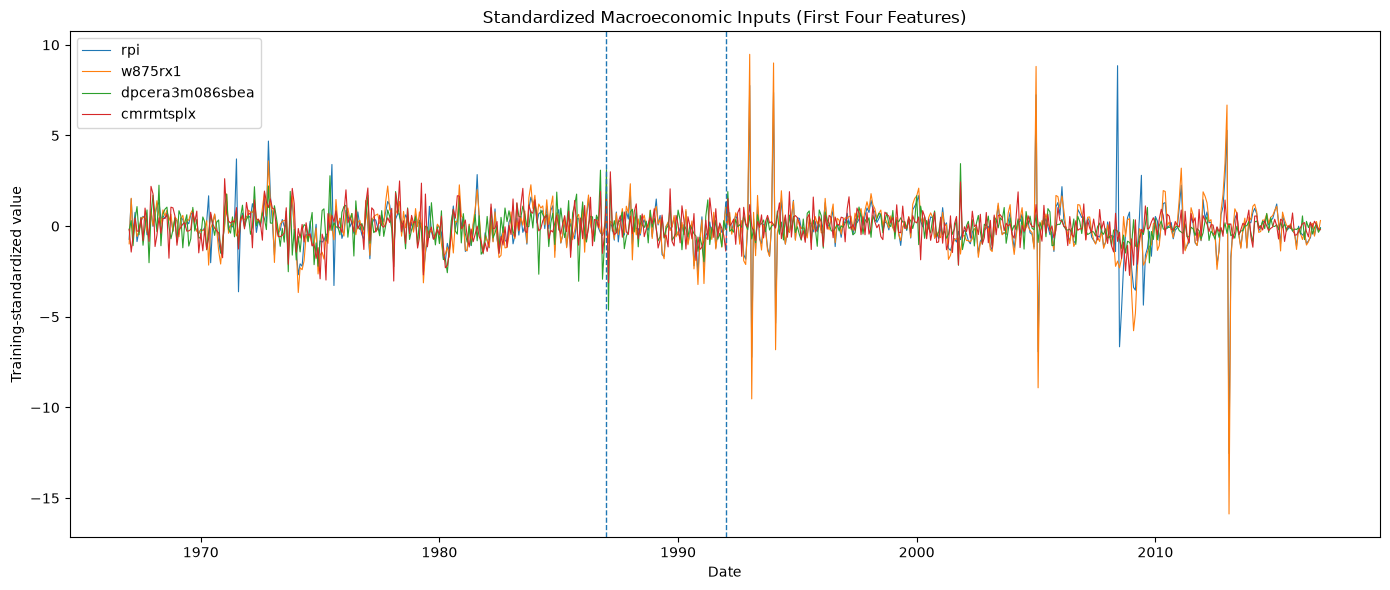

In [37]:
plot_features = macro_feature_cols[:4]

plt.figure(figsize=(14, 6))

for feature in plot_features:
    plt.plot(
        macro_standardized[DATE_COL],
        macro_standardized[feature],
        linewidth=0.8,
        label=feature,
    )

plt.axvline(
    VALID_START,
    linestyle="--",
    linewidth=1,
)

plt.axvline(
    TEST_START,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Standardized Macroeconomic Inputs "
    "(First Four Features)"
)

plt.xlabel("Date")
plt.ylabel("Training-standardized value")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Save the prepared macro-LSTM inputs

We save the standardized 600-month panel and the **training-only** scaling statistics.

We deliberately do **not** save the untrained hidden states from Sections 15–17. Final hidden states must come from the trained GAN in Code 06.

In [38]:
macro_input_path = (
    MACRO_DIR
    / "macro_lstm_input.parquet"
)

macro_stats_path = (
    TABLES_DIR
    / "macro_standardization_stats.csv"
)

macro_diag_path = (
    TABLES_DIR
    / "macro_input_diagnostics.csv"
)

macro_config_path = (
    MODELS_DIR
    / "lstm_macro_config.json"
)

macro_standardized[
    [DATE_COL] + macro_feature_cols
].to_parquet(
    macro_input_path,
    index=False,
)

macro_stats = pd.DataFrame(
    {
        "feature": macro_feature_cols,
        "train_mean": train_mean,
        "train_std": train_std,
        "safe_train_std": safe_train_std,
        "zero_std_feature": zero_std_mask,
    }
)

macro_stats.to_csv(
    macro_stats_path,
    index=False,
)

macro_input_diagnostics.to_csv(
    macro_diag_path,
    index=False,
)

macro_config = {
    "date_column": DATE_COL,
    "macro_feature_count": len(
        macro_feature_cols
    ),
    "macro_features": macro_feature_cols,
    "sdf_macro_hidden_dim": (
        SDF_MACRO_HIDDEN_DIM
    ),
    "conditional_macro_hidden_dim": (
        COND_MACRO_HIDDEN_DIM
    ),
    "lstm_num_layers": LSTM_NUM_LAYERS,
    "standardization": (
        "training_mean_and_population_std"
    ),
    "training_period": [
        "1967-01-01",
        "1986-12-01",
    ],
    "validation_period": [
        "1987-01-01",
        "1991-12-01",
    ],
    "test_period": [
        "1992-01-01",
        "2016-12-01",
    ],
    "state_carryover": (
        "train_to_validation_to_test"
    ),
    "standalone_lstm_training": False,
    "final_hidden_states_trained_in": (
        "06_gan_asset_pricing.ipynb"
    ),
}

with open(
    macro_config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        macro_config,
        file,
        indent=2,
    )

print("Saved:", macro_input_path)
print("Saved:", macro_stats_path)
print("Saved:", macro_diag_path)
print("Saved:", macro_config_path)

Saved: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/macro/macro_lstm_input.parquet
Saved: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables/macro_standardization_stats.csv
Saved: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables/macro_input_diagnostics.csv
Saved: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/models/lstm_macro_config.json


## 21. Replication checklist

This checklist verifies the macroeconomic input and recurrent-state infrastructure required by Code 06.

In [39]:
print()
print("=" * 60)
print("LSTM MACRO-STATE PREPARATION CHECKLIST")
print("=" * 60)

assert len(macro) == 600

assert len(macro_train) == 240
assert len(macro_valid) == 60
assert len(macro_test) == 300

assert (
    len(macro_feature_cols)
    == EXPECTED_MACRO_FEATURES
), (
    f"Expected {EXPECTED_MACRO_FEATURES} "
    f"macro features, found "
    f"{len(macro_feature_cols)}."
)

assert np.isfinite(
    macro_standardized[
        macro_feature_cols
    ].to_numpy(dtype=float)
).all()

assert (
    SDF_MACRO_HIDDEN_DIM
    == 4
)

assert (
    COND_MACRO_HIDDEN_DIM
    == 32
)

assert (
    LSTM_NUM_LAYERS
    == 1
)

assert (
    carryover_max_difference
    < 1e-6
)

assert (
    past_difference
    < 1e-6
)

expected_outputs = [
    macro_input_path,
    macro_stats_path,
    macro_diag_path,
    macro_config_path,
]

missing_outputs = [
    path
    for path in expected_outputs
    if not path.exists()
]

assert not missing_outputs, (
    "Missing output files:\n"
    + "\n".join(
        str(path)
        for path in missing_outputs
    )
)

print("✓ 178 macroeconomic predictors")
print("✓ Exact 1967–2016 monthly sample")
print("✓ 240 / 60 / 300 chronological split")
print("✓ Training-only standardization")
print("✓ SDF LSTM hidden dimension = 4")
print("✓ Conditional LSTM hidden dimension = 32")
print("✓ Recurrent state carried across splits")
print("✓ Full-vs-split recurrent equivalence")
print("✓ No-look-ahead causality test")
print("✓ Prepared macro inputs saved")
print()
print(
    "✓ Ready for 06_gan_asset_pricing.ipynb"
)


LSTM MACRO-STATE PREPARATION CHECKLIST
✓ 178 macroeconomic predictors
✓ Exact 1967–2016 monthly sample
✓ 240 / 60 / 300 chronological split
✓ Training-only standardization
✓ SDF LSTM hidden dimension = 4
✓ Conditional LSTM hidden dimension = 32
✓ Recurrent state carried across splits
✓ Full-vs-split recurrent equivalence
✓ No-look-ahead causality test
✓ Prepared macro inputs saved

✓ Ready for 06_gan_asset_pricing.ipynb


## 22. What Code 06 will do

`06_gan_asset_pricing.ipynb` will use this prepared macro panel inside the actual asset-pricing networks.

The GAN stage will:

1. load the 46 firm characteristics and excess stock returns;
2. load the 178 standardized macro inputs prepared here;
3. encode macro history with a 4-state LSTM in the SDF network;
4. encode macro history with a 32-state LSTM in the adversarial conditioning network;
5. combine macro states with firm characteristics;
6. train the SDF and conditioning networks using the no-arbitrage moment objective;
7. form the tradeable SDF factor;
8. evaluate Sharpe ratio, explained variation, cross-sectional pricing performance, and hidden-state dynamics;
9. save the **trained** macro hidden states for interpretation and Code 07.

This separation keeps Code 05 focused on causal macro-state infrastructure while ensuring that the final hidden states are estimated using the paper's asset-pricing objective rather than an unrelated standalone target.

## Conclusion

This notebook completes the macroeconomic-state preparation required for the recurrent asset-pricing model.

The main validation checks confirm that:

- the macro information set contains the expected **178 variables and 600 months**;
- the **240 / 60 / 300** train-validation-test split is correct;
- the processed macro panel matches the author-provided macro arrays numerically;
- all macro observations are finite and no training feature has zero variance;
- standardization is estimated using the training sample only;
- the LSTM receives tensors with the expected `(batch, time, features)` structure;
- the SDF macro encoder uses **4 hidden states**, while the conditional encoder uses **32 hidden states**;
- carrying recurrent states across train → validation → test is exactly equivalent to processing the full 600-month sequence continuously;
- perturbing future macro observations does not alter earlier hidden states, confirming the absence of look-ahead leakage.

Large out-of-sample standardized macro shocks, including the extreme `nonborres` observations during the financial crisis, are intentionally preserved because they are part of the original author data.

### Handoff to Notebook 06

Notebook 05 establishes the macroeconomic input pipeline and validates the recurrent architecture. The next step is to combine these macro states with the firm-level characteristic and return data in the GAN asset-pricing model.

The LSTM parameters should be learned jointly with the pricing objective in Notebook 06 rather than treating the preliminary hidden states produced here as final economic state variables.